# 📊 Milestone 1: Employee Attrition - EDA & Preprocessing

## 🎯 Objective
This notebook focuses on exploring, cleaning, and preprocessing the employee dataset to prepare it for machine learning models. 

## 📌 Workflow
1. **Data Collection:** Load the dataset.
2. **Exploratory Data Analysis (EDA):** Understand distributions and detect patterns.
3. **Data Cleaning:** Handle missing values, outliers, and drop redundant features.
4. **Feature Engineering:** Create new insightful features (e.g., Tenure Groups, Salary-to-Performance Ratio).
5. **Encoding:** Convert categorical variables into numerical format.
6. **Save:** Export the fully preprocessed dataset.

In [1]:
# Import fundamental libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Set visual style for professional plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

## 📥 1. Load Dataset
Loading the raw dataset saved from our initial project setup.

In [2]:
# Load the dataset
df = pd.read_csv("../data/raw/employee_attrition_raw.csv")

# Display the first 5 rows to ensure correct loading
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 📊 2. Dataset Overview
Understanding the shape, data types, and basic statistics of our features.

In [3]:
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")

print("--- Data Types & Non-Null Counts ---")
df.info()

print("\n--- Summary Statistics ---")
display(df.describe().T)

Dataset Shape: 1470 Rows, 35 Columns

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  Job

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## 🔍 3. Exploratory Data Analysis (EDA)
Analyzing the target variable and its relationship with key features.

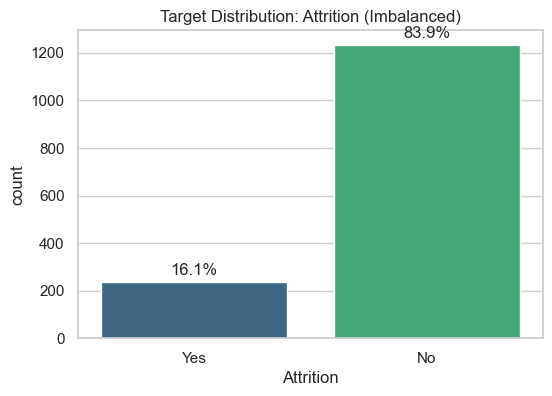

In [4]:
# 1. Target Distribution (Attrition)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Attrition', hue='Attrition', palette='viridis', legend=False)
plt.title("Target Distribution: Attrition (Imbalanced)")

# Add percentages on bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, xytext=(0, 5), textcoords='offset points')
plt.show()

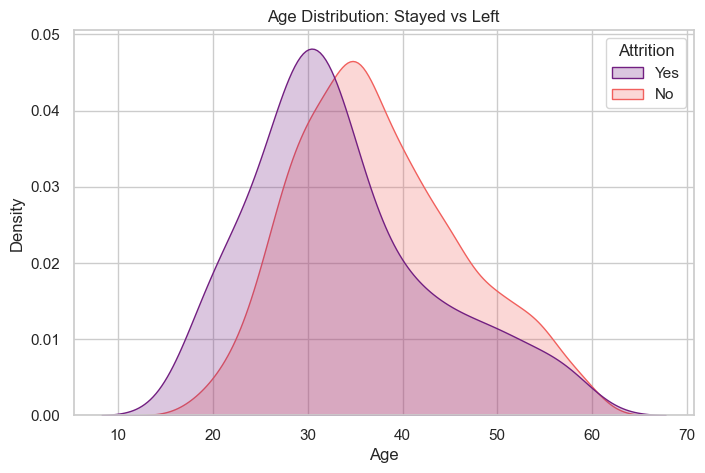

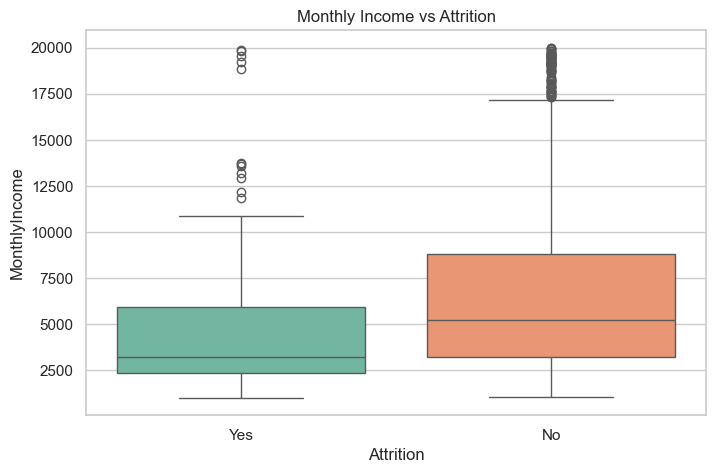

In [5]:
# 2. Age Distribution by Attrition
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Attrition', fill=True, common_norm=False, palette='magma')
plt.title('Age Distribution: Stayed vs Left')
plt.show()

# 3. Income vs Attrition
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Monthly Income vs Attrition')
plt.show()

### 🏢 3.1 Categorical Features Analysis (Job Role, Department, Business Travel)
Let's see how different roles and travel frequencies impact attrition.

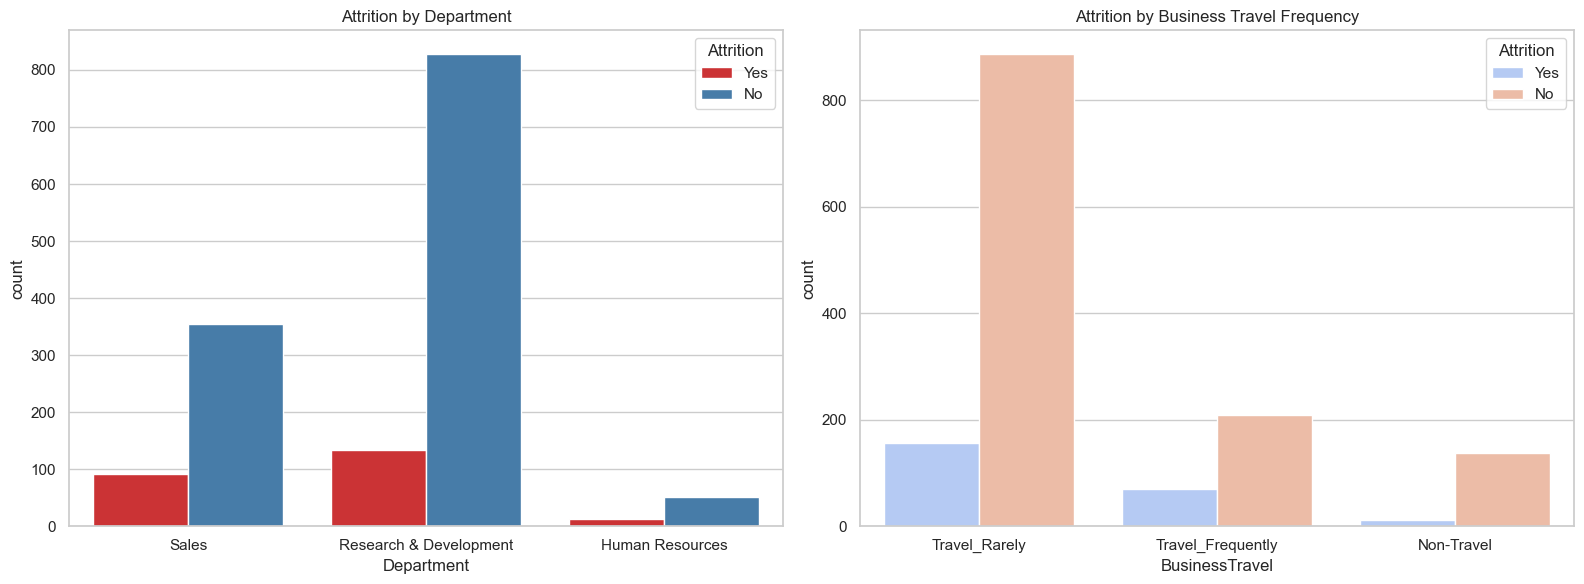

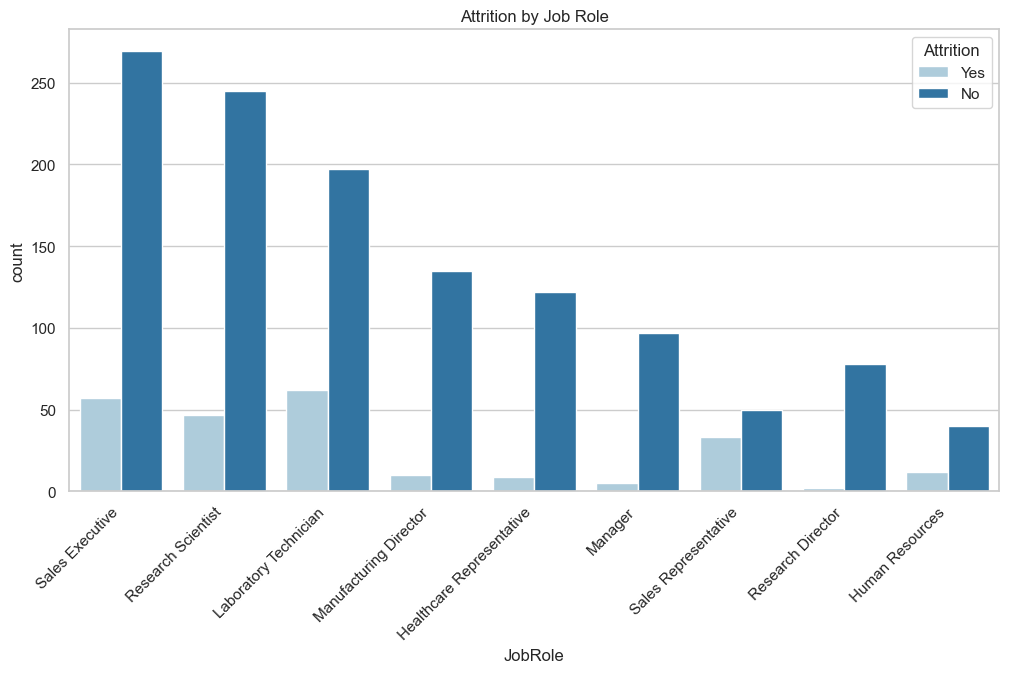

In [6]:
# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Department vs Attrition
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set1', ax=axes[0])
axes[0].set_title('Attrition by Department')

# Plot 2: Business Travel vs Attrition
sns.countplot(data=df, x='BusinessTravel', hue='Attrition', palette='coolwarm', ax=axes[1])
axes[1].set_title('Attrition by Business Travel Frequency')

plt.tight_layout()
plt.show()

# Plot 3: Job Role vs Attrition (Needs a separate plot because of many categories)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='JobRole', hue='Attrition', palette='Paired')
plt.title('Attrition by Job Role')
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.show()

### 🔥 3.2 Correlation Heatmap
To understand how numerical features relate to each other, we use a correlation heatmap. 
*Note: We will encode 'Attrition' temporarily just for this correlation check.*

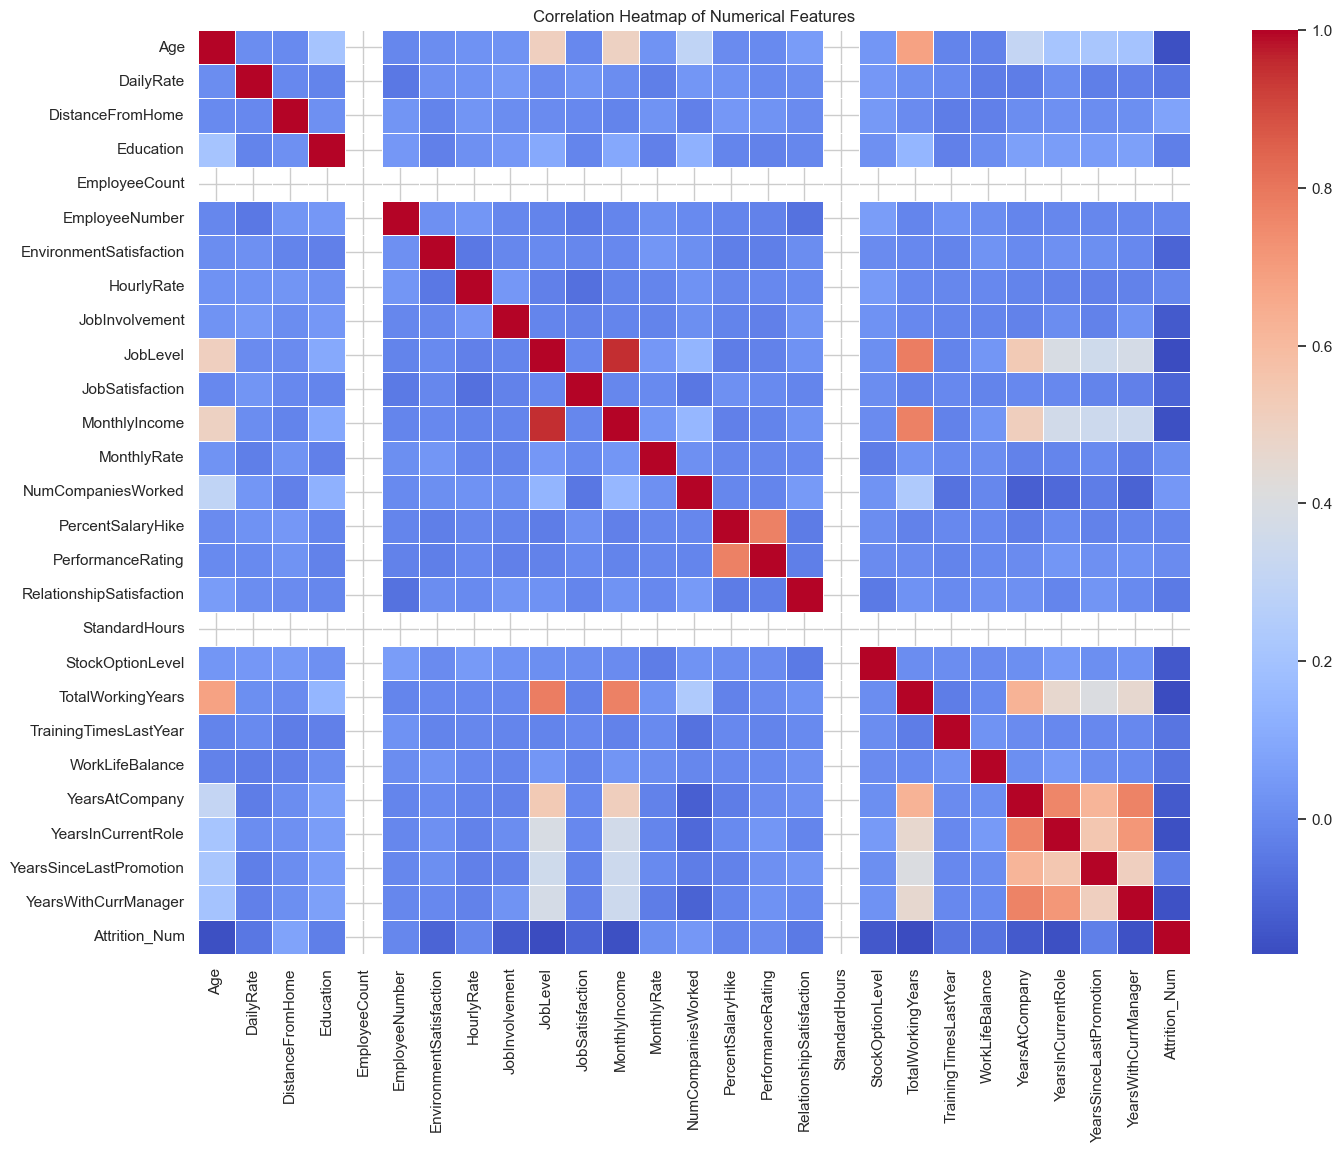

Top 5 Factors Correlated with Attrition:


DistanceFromHome      0.077924
NumCompaniesWorked    0.043494
MonthlyRate           0.015170
PerformanceRating     0.002889
HourlyRate           -0.006846
Name: Attrition_Num, dtype: float64

In [7]:
# Create a temporary dataframe for correlation to avoid messing up our main df yet
corr_df = df.copy()

# Convert Attrition to 1 and 0 just for the heatmap
corr_df['Attrition_Num'] = corr_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select only numerical columns
numerical_cols = corr_df.select_dtypes(include=['int64', 'float64']).columns

# Calculate correlation matrix
corr_matrix = corr_df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Let's see the top 5 features most correlated with Attrition
print("Top 5 Factors Correlated with Attrition:")
display(corr_matrix['Attrition_Num'].sort_values(ascending=False).head(6)[1:]) # Excluding Attrition itself

💡 **Additional Insights:**
* **Job Role & Dept:** Sales Representatives and Lab Technicians show a notably higher proportion of attrition.
* **Travel:** Employees who travel 'Frequently' have a much higher attrition rate compared to those who travel rarely or not at all.
* **Correlation:** We can see that variables like 'TotalWorkingYears', 'JobLevel', and 'MonthlyIncome' are highly correlated with each other (Multicollinearity).

## 🧹 4. Data Cleaning
Handling missing values, duplicate rows, and removing zero-variance (constant) features.

In [8]:
# Check for missing values
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values: {missing_values}")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Total Duplicates: {duplicates}")

# Drop constant features (e.g., Over18, EmployeeCount) and IDs
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped redundant columns. New shape: {df.shape}")

Total Missing Values: 0
Total Duplicates: 0
Dropped redundant columns. New shape: (1470, 31)


## 📈 5. Outlier Detection & Handling
`MonthlyIncome` often contains outliers (executives with massive salaries) that can skew machine learning models.

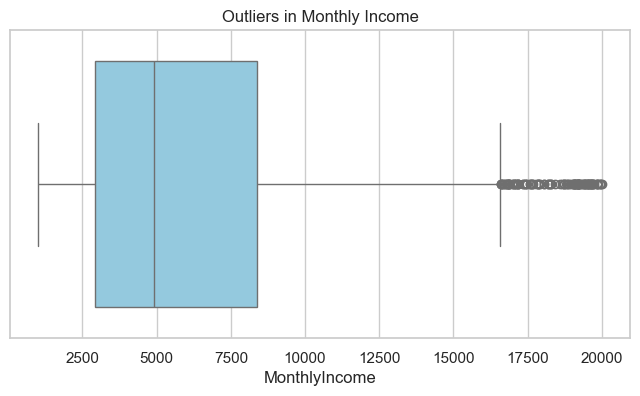

Applied Log Transformation to MonthlyIncome to handle outliers.


In [9]:
# Detect Outliers using Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['MonthlyIncome'], color='skyblue')
plt.title("Outliers in Monthly Income")
plt.show()

# Handle Outliers: Log Transformation to normalize the distribution
df['MonthlyIncome_Log'] = np.log1p(df['MonthlyIncome'])

# Drop the original skewed column
df.drop(columns=['MonthlyIncome'], inplace=True)
print("Applied Log Transformation to MonthlyIncome to handle outliers.")

## ⚙️ 6. Feature Engineering
Creating new insightful features as requested in the project specifications.

In [10]:
# Feature 1: Tenure Categories
def categorize_tenure(years):
    if years < 3: return 'Short-term'
    elif years <= 7: return 'Medium-term'
    else: return 'Long-term'

df['Tenure_Category'] = df['YearsAtCompany'].apply(categorize_tenure)

# Feature 2: Salary to Performance Ratio (using the transformed Log Income)
# This shows how well-compensated an employee is relative to their performance
df['Income_Performance_Ratio'] = df['MonthlyIncome_Log'] / df['PerformanceRating']

print("Successfully engineered new features: 'Tenure_Category' and 'Income_Performance_Ratio'")

Successfully engineered new features: 'Tenure_Category' and 'Income_Performance_Ratio'


### 🖱️ 6.1 Interactive Visualization (Plotly)
To deeply explore the relationship between Age, Income, and Attrition interactively, as required by the project specifications.

In [11]:
# pip install plotly
import plotly.express as px

# Create an interactive scatter plot
fig = px.scatter(df, 
                 x='Age', 
                 y='MonthlyIncome_Log', 
                 color='Attrition',
                 hover_data=['JobRole', 'Department', 'YearsAtCompany'],
                 title='Interactive Explorer: Age vs Log(Income) colored by Attrition',
                 opacity=0.7,
                 color_discrete_map={'Yes': 'red', 'No': 'blue'})

fig.update_layout(template='plotly_white')
fig.show()

## 🔤 7. Encoding Categorical Features
Machine learning models require numerical inputs. We convert text variables into dummy variables (0 and 1).

In [12]:
# One-Hot Encoding for categorical variables
# drop_first=True prevents multicollinearity (the dummy variable trap)
df_encoded = pd.get_dummies(df, drop_first=True)

# Rename the target column for clarity (Attrition_Yes will be 1 if they left, 0 if stayed)
if 'Attrition_Yes' in df_encoded.columns:
    df_encoded.rename(columns={'Attrition_Yes': 'Target_Attrition'}, inplace=True)

print(f"Data shape after encoding: {df_encoded.shape}")

Data shape after encoding: (1470, 48)


### 📏 7.1 Normalizing Numerical Features
Machine learning models perform better when numerical features are on a similar scale. We will use `StandardScaler` to normalize continuous variables like Age and DistanceFromHome.

In [13]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Select columns that have large numerical ranges (excluding binary/encoded columns)
cols_to_scale = ['Age', 'DistanceFromHome', 'YearsAtCompany', 'TotalWorkingYears', 'NumCompaniesWorked']

# Apply scaling
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

print("Features normalized successfully! Mean is now ~0 and Standard Deviation is 1.")
display(df_encoded[cols_to_scale].head())

Features normalized successfully! Mean is now ~0 and Standard Deviation is 1.


,Age,DistanceFromHome,YearsAtCompany,TotalWorkingYears,NumCompaniesWorked
0,0.446350,-1.010909,-0.164613,-0.421642,2.125136
1,1.322365,-0.147150,0.488508,-0.164511,-0.678049
2,0.008343,-0.887515,-1.144294,-0.550208,1.324226
3,-0.429664,-0.764121,0.161947,-0.421642,-0.678049
4,-1.086676,-0.887515,-0.817734,-0.678774,2.525591


## 💾 8. Save Processed Dataset
The dataset is now cleaned, engineered, and encoded. We will save it for Milestone 2 & 3.

In [14]:
import os

# Ensure directory exists
os.makedirs('../data/processed', exist_ok=True)

# Save the final dataset
save_path = "../data/processed/employee_attrition_processed.csv"
df_encoded.to_csv(save_path, index=False)

print(f"✅ Cleaned and Processed dataset saved successfully to: {save_path}")

✅ Cleaned and Processed dataset saved successfully to: ../data/processed/employee_attrition_processed.csv


## 📝 9. Final EDA Report Summary
**1. Data Quality:** The dataset was clean with no missing values, but contained redundant constant features (e.g., Over18) which were removed.
**2. Target Imbalance:** Attrition is highly imbalanced (16% Yes, 84% No), requiring advanced handling (SMOTE) in the modeling phase.
**3. Key Drivers of Attrition:**
* **Demographics:** Younger employees (<30 years) have a higher attrition rate.
* **Financials:** Lower monthly income strongly correlates with leaving the company.
* **Work Environment:** Frequent business travelers and specific roles (Sales Reps, Lab Techs) show higher turnover.
**4. Transformations:** We successfully engineered new features (Tenure Category, Income/Performance Ratio), normalized numerical data, and encoded categorical variables to prepare for modeling.